# 04 · Evaluation lab

Here is the heart of the imbalanced-learning lesson. We first rank the models by **accuracy** — and they all look superb. Then we switch to metrics that respect the imbalance (**AUC-PR**, recall, F1) and the ranking changes completely.

We plot:
- Precision–recall curves (the right curve for rare positives)
- ROC curves (the popular-but-optimistic curve)
- Calibration curves (are the probabilities trustworthy?)
- A confusion-matrix grid at threshold 0.5

All from the saved scores in `03_scores.parquet` — no retraining.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import fraud_utils as fu

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid")
ART = fu.ARTIFACTS_DIR
RNG = np.random.default_rng(42)

In [2]:
scores = pd.read_parquet(os.path.join(ART, '03_scores.parquet'))
y = scores['y_true'].values
model_cols = [c for c in scores.columns if c != 'y_true']
print('models:', model_cols)
print('test fraud rate:', y.mean())

models: ['logreg', 'tree', 'random_forest', 'xgboost', 'nn_plain', 'nn_reg']
test fraud rate: 0.0033222591362126247


## Step 1 — rank by accuracy (the trap)

Predict fraud when probability ≥ 0.5, then compute accuracy. Watch every model post a number north of 99%. If you stopped here you'd think the problem was solved.

In [3]:
from sklearn.metrics import accuracy_score
acc = {m: accuracy_score(y, (scores[m] >= 0.5).astype(int)) for m in model_cols}
acc_s = pd.Series(acc).sort_values(ascending=False)
print(acc_s.to_string())
print(f"\nBaseline 'always legit' accuracy: {1 - y.mean():.4%}")

xgboost         0.9990
nn_plain        0.9985
random_forest   0.9980
nn_reg          0.9972
tree            0.9902
logreg          0.9658

Baseline 'always legit' accuracy: 99.6678%


## Step 2 — the metrics that actually matter

Now the full table. `auc_pr` (average precision) is the headline number for rare-event detection: it summarises precision across all recall levels and is not fooled by the huge legit majority.

In [4]:
rows = []
for m in model_cols:
    met = fu.evaluate_scores(y, scores[m].values, threshold=0.5)
    met['model'] = m
    rows.append(met)
table = (pd.DataFrame(rows).set_index('model')
         .sort_values('auc_pr', ascending=False))
table[['accuracy', 'precision', 'recall', 'f1', 'auc_roc', 'auc_pr']]

,accuracy,precision,recall,f1,auc_roc,auc_pr
model,,,,,,
xgboost,0.9990,0.8723,0.8200,0.8454,0.9963,0.9255
nn_plain,0.9985,0.7800,0.7800,0.7800,0.9953,0.8440
nn_reg,0.9972,0.5556,0.8000,0.6557,0.9869,0.8342
random_forest,0.9980,1.0000,0.4000,0.5714,0.9939,0.8203
logreg,0.9658,0.0751,0.8200,0.1376,0.9554,0.7177
tree,0.9902,0.2216,0.7800,0.3451,0.8171,0.3855


Notice how the **accuracy** column is nearly flat and useless, while **auc_pr** spreads the models out and often reorders them. The model that won on accuracy is rarely the one that wins on AUC-PR.

## Precision–recall curves

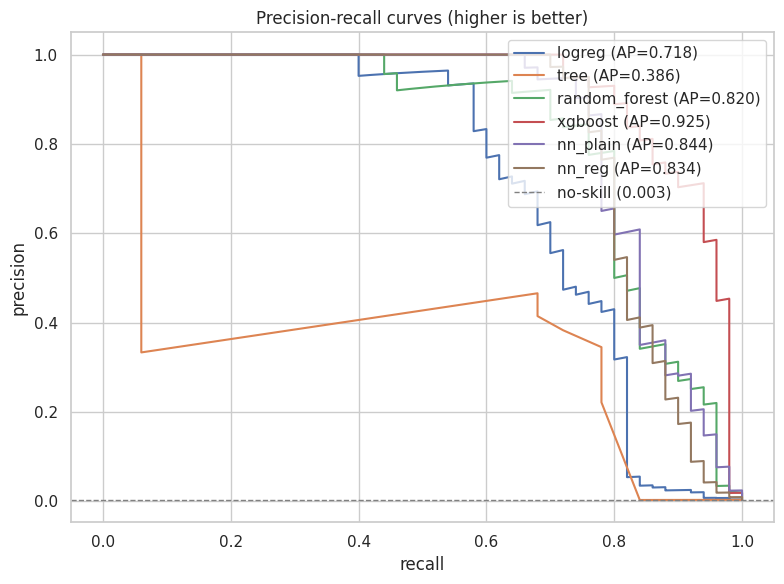

In [5]:
from sklearn.metrics import precision_recall_curve, average_precision_score
fig, ax = plt.subplots(figsize=(8, 6))
for m in model_cols:
    prec, rec, _ = precision_recall_curve(y, scores[m])
    ap = average_precision_score(y, scores[m])
    ax.plot(rec, prec, label=f'{m} (AP={ap:.3f})')
ax.axhline(y.mean(), ls='--', color='gray', lw=1,
           label=f'no-skill ({y.mean():.3f})')
ax.set_xlabel('recall'); ax.set_ylabel('precision')
ax.set_title('Precision-recall curves (higher is better)')
ax.legend(loc='upper right'); plt.tight_layout(); plt.show()

## ROC curves

ROC looks flattering on imbalanced data because the false-positive rate has a giant denominator. Useful, but never your only lens.

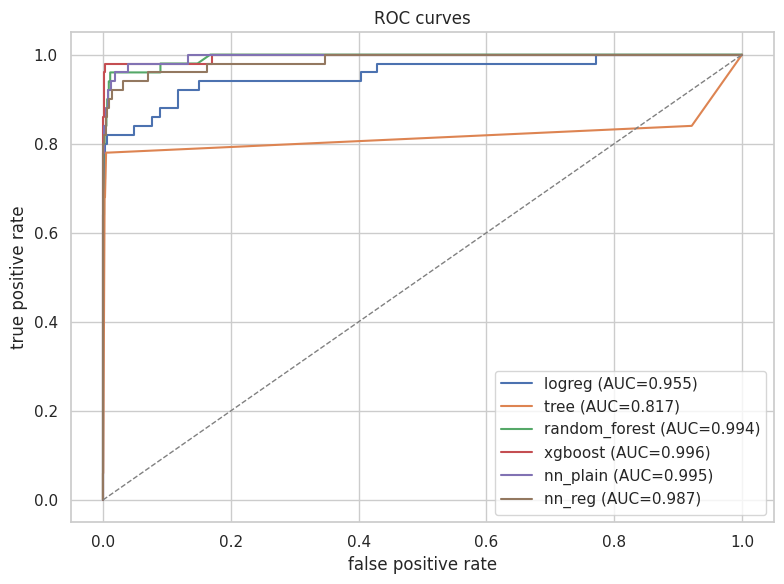

In [6]:
from sklearn.metrics import roc_curve, roc_auc_score
fig, ax = plt.subplots(figsize=(8, 6))
for m in model_cols:
    fpr, tpr, _ = roc_curve(y, scores[m])
    auc = roc_auc_score(y, scores[m])
    ax.plot(fpr, tpr, label=f'{m} (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], ls='--', color='gray', lw=1)
ax.set_xlabel('false positive rate'); ax.set_ylabel('true positive rate')
ax.set_title('ROC curves'); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

## Calibration

A well-calibrated model that says "0.8" is right about 80% of the time. This matters for the business layer: notebook 06 turns probabilities into money, so the probabilities need to mean something. Tree ensembles are often over-confident; logistic regression is usually well-calibrated.

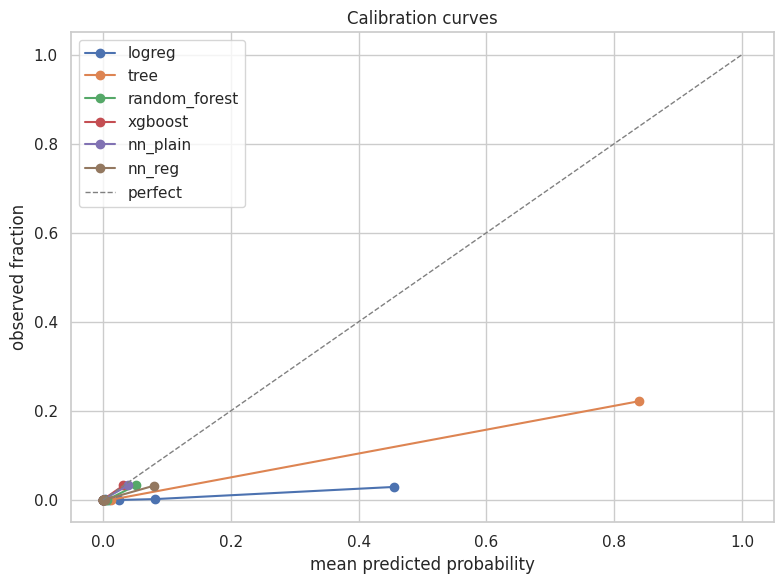

In [7]:
from sklearn.calibration import calibration_curve
fig, ax = plt.subplots(figsize=(8, 6))
for m in model_cols:
    frac_pos, mean_pred = calibration_curve(y, scores[m], n_bins=10,
                                            strategy='quantile')
    ax.plot(mean_pred, frac_pos, marker='o', label=m)
ax.plot([0, 1], [0, 1], ls='--', color='gray', lw=1, label='perfect')
ax.set_xlabel('mean predicted probability'); ax.set_ylabel('observed fraction')
ax.set_title('Calibration curves'); ax.legend()
plt.tight_layout(); plt.show()

## Confusion matrices at threshold 0.5

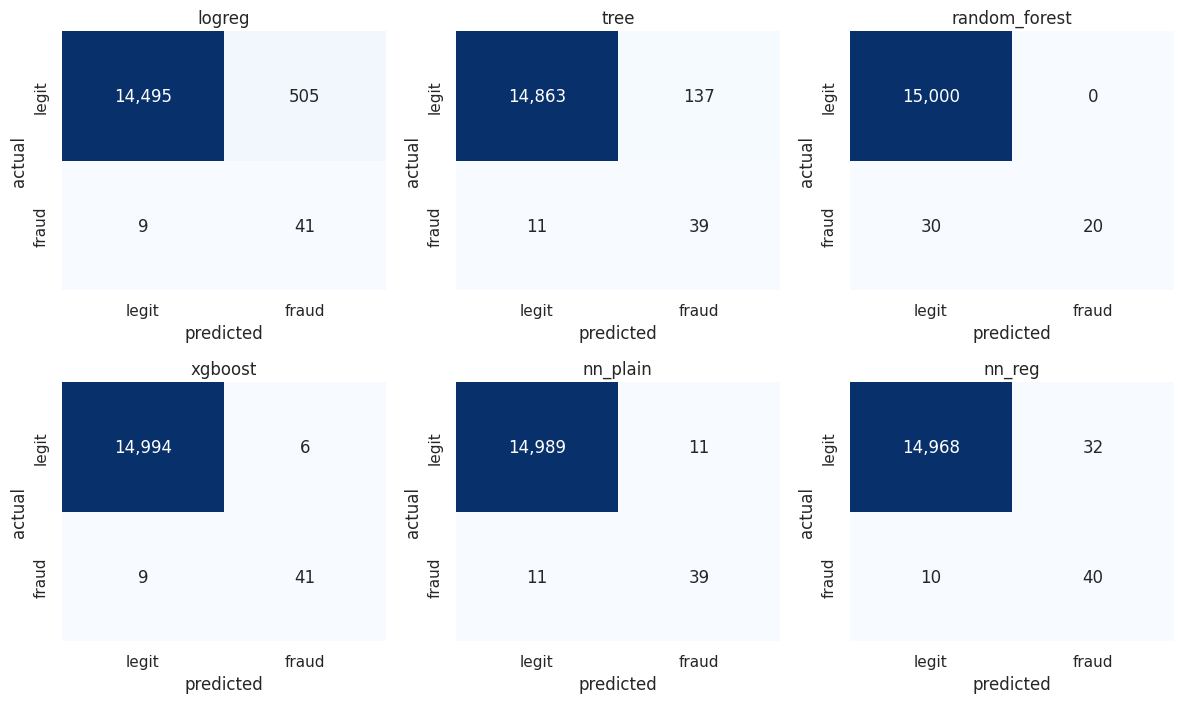

In [8]:
from sklearn.metrics import confusion_matrix
n = len(model_cols)
cols = 3; rows_n = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows_n, cols, figsize=(12, 3.6 * rows_n))
axes = np.array(axes).ravel()
for i, m in enumerate(model_cols):
    cm = confusion_matrix(y, (scores[m] >= 0.5).astype(int), labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=False,
                ax=axes[i], xticklabels=['legit', 'fraud'],
                yticklabels=['legit', 'fraud'])
    axes[i].set_title(m); axes[i].set_xlabel('predicted'); axes[i].set_ylabel('actual')
for j in range(n, len(axes)):
    axes[j].axis('off')
plt.tight_layout(); plt.show()

In [9]:
out = os.path.join(ART, '04_metrics.parquet')
table.to_parquet(out)
best = table['auc_pr'].idxmax()
print('saved', out)
print('best model by AUC-PR on the random split:', best)

saved /home/claude/fraud-detection-research/artifacts/04_metrics.parquet
best model by AUC-PR on the random split: xgboost


### Takeaways
- **Accuracy is a liar on imbalanced data** — every model clears 99%.
- **AUC-PR** is the honest ranking and usually crowns a tree ensemble.
- Calibration tells you whether the probabilities can be trusted as money later.

But this whole ranking assumes the future looks like the past. Next notebook breaks that assumption.